# Matched-label random-frame coverage control

## tl;dr

The frozen systematic first-frame treatment reduced the median paired system-level coverage distance by **49.73%** in FCC-to-BCC and **55.16%** in BCC-to-FCC. Across 10,000 matched pooled random-frame draws, the corresponding medians were **62.13%** [61.20, 62.81] and **63.33%** [62.16, 66.73]. Every pooled random draw exceeded the systematic value in both folds. Randomizing the time point while retaining exactly one frame per trajectory also exceeded the systematic first-frame result. The coverage gain therefore cannot be attributed to a special advantage of the first-frame selection; these controls remain within POCC-derived trajectories and do not compare POCC against random-alloy or SQS structure generation.

## Context & Methods

The PI requested a matched-label reference for the existing structural-coverage claim. The analysis preserves the frozen 150-dimensional, label-blind, central-element-stratified radial descriptor and the original every-100th-frame temporal-thinning variants. For each draw, 29 FCC-parent or 30 BCC-parent frames replace the systematic first frames, and coverage is recomputed on the complete opposite-parent held-out systems. The fold statistic is the median of paired system-level relative reductions in median nearest-training distance.

### Key Assumptions

- The temporally thinned candidate pool is the governing frame population because it is the population fixed for the original coverage analysis; thinning reduces serial dependence but does not establish independence.
- The primary pooled control samples distinct frames uniformly, so long trajectories receive more candidate weight and a draw can omit systems.
- The one-per-trajectory sensitivity holds chemical-system breadth fixed and randomizes only the retained time point.
- No energy, force, virial, model output, new DFT label, or model training enters the control.
- Empirical draw intervals describe selection variability in these frozen trajectories; they are not population confidence intervals.

The full locked protocol is in `../analysis_protocol.md`.

## Data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display

cwd = Path.cwd().resolve()
PACKAGE = cwd if (cwd / 'results').is_dir() else cwd.parent
RESULTS = PACKAGE / 'results'
summary = pd.read_csv(RESULTS / 'control_summary.csv')
draws = pd.read_csv(RESULTS / 'random_draw_distribution.csv.gz')
candidates = pd.read_csv(RESULTS / 'candidate_frames.csv')
trajectories = pd.read_csv(RESULTS / 'trajectory_manifest.csv')
frames = pd.read_csv(RESULTS / 'frame_manifest.csv')
seed_check = pd.read_csv(RESULTS / 'systematic_seed_reconstruction.csv')
print(f'{len(draws):,} random-draw rows; {len(candidates)} candidate frames; '+ f'{len(trajectories)} trajectories; {len(frames)} CIF frames')
display(seed_check)

40,000 random-draw rows; 415 candidate frames; 103 trajectories; 577 CIF frames


,fold,frozen_seed_reduction_fraction,recomputed_seed_reduction_fraction,absolute_fold_difference,maximum_environment_distance_difference,systematic_frame_count,status
0,fcc_to_bcc,0.497298,0.497298,0.0,0.0,29,passed
1,bcc_to_fcc,0.551573,0.551573,0.0,0.0,30,passed


## Results

In [2]:
derived = (draws.groupby(['fold', 'control'])['coverage_reduction_percent']
           .agg(random_median='median', random_q025=lambda x: x.quantile(0.025),
                random_q975=lambda x: x.quantile(0.975)).reset_index())
checked = summary.merge(derived, on=['fold', 'control'], validate='one_to_one')
assert np.allclose(checked.random_median, checked.random_median_reduction_percent)
assert np.allclose(checked.random_q025, checked.random_q025_reduction_percent)
assert np.allclose(checked.random_q975, checked.random_q975_reduction_percent)
columns = ['fold_label', 'control', 'systematic_seed_reduction_percent',
           'random_median_reduction_percent', 'random_q025_reduction_percent',
           'random_q975_reduction_percent',
           'systematic_minus_random_median_percentage_points',
           'systematic_empirical_percentile',
           'one_sided_p_random_ge_systematic']
display(summary[columns].round(4))

,fold_label,control,systematic_seed_reduction_percent,random_median_reduction_percent,random_q025_reduction_percent,random_q975_reduction_percent,systematic_minus_random_median_percentage_points,systematic_empirical_percentile,one_sided_p_random_ge_systematic
0,FCC-to-BCC,pooled_random_frames,49.7298,62.1325,61.1972,62.8131,-12.4027,0.0,1.0
1,FCC-to-BCC,one_per_trajectory,49.7298,62.1143,61.3889,62.6039,-12.3846,0.0,1.0
2,BCC-to-FCC,pooled_random_frames,55.1573,63.3266,62.1649,66.7306,-8.1692,0.0,1.0
3,BCC-to-FCC,one_per_trajectory,55.1573,65.8277,64.4826,66.8104,-10.6703,0.0,1.0


fcc_to_bcc: 10,000/10,000 pooled draws exceed the systematic first-frame value
bcc_to_fcc: 10,000/10,000 pooled draws exceed the systematic first-frame value


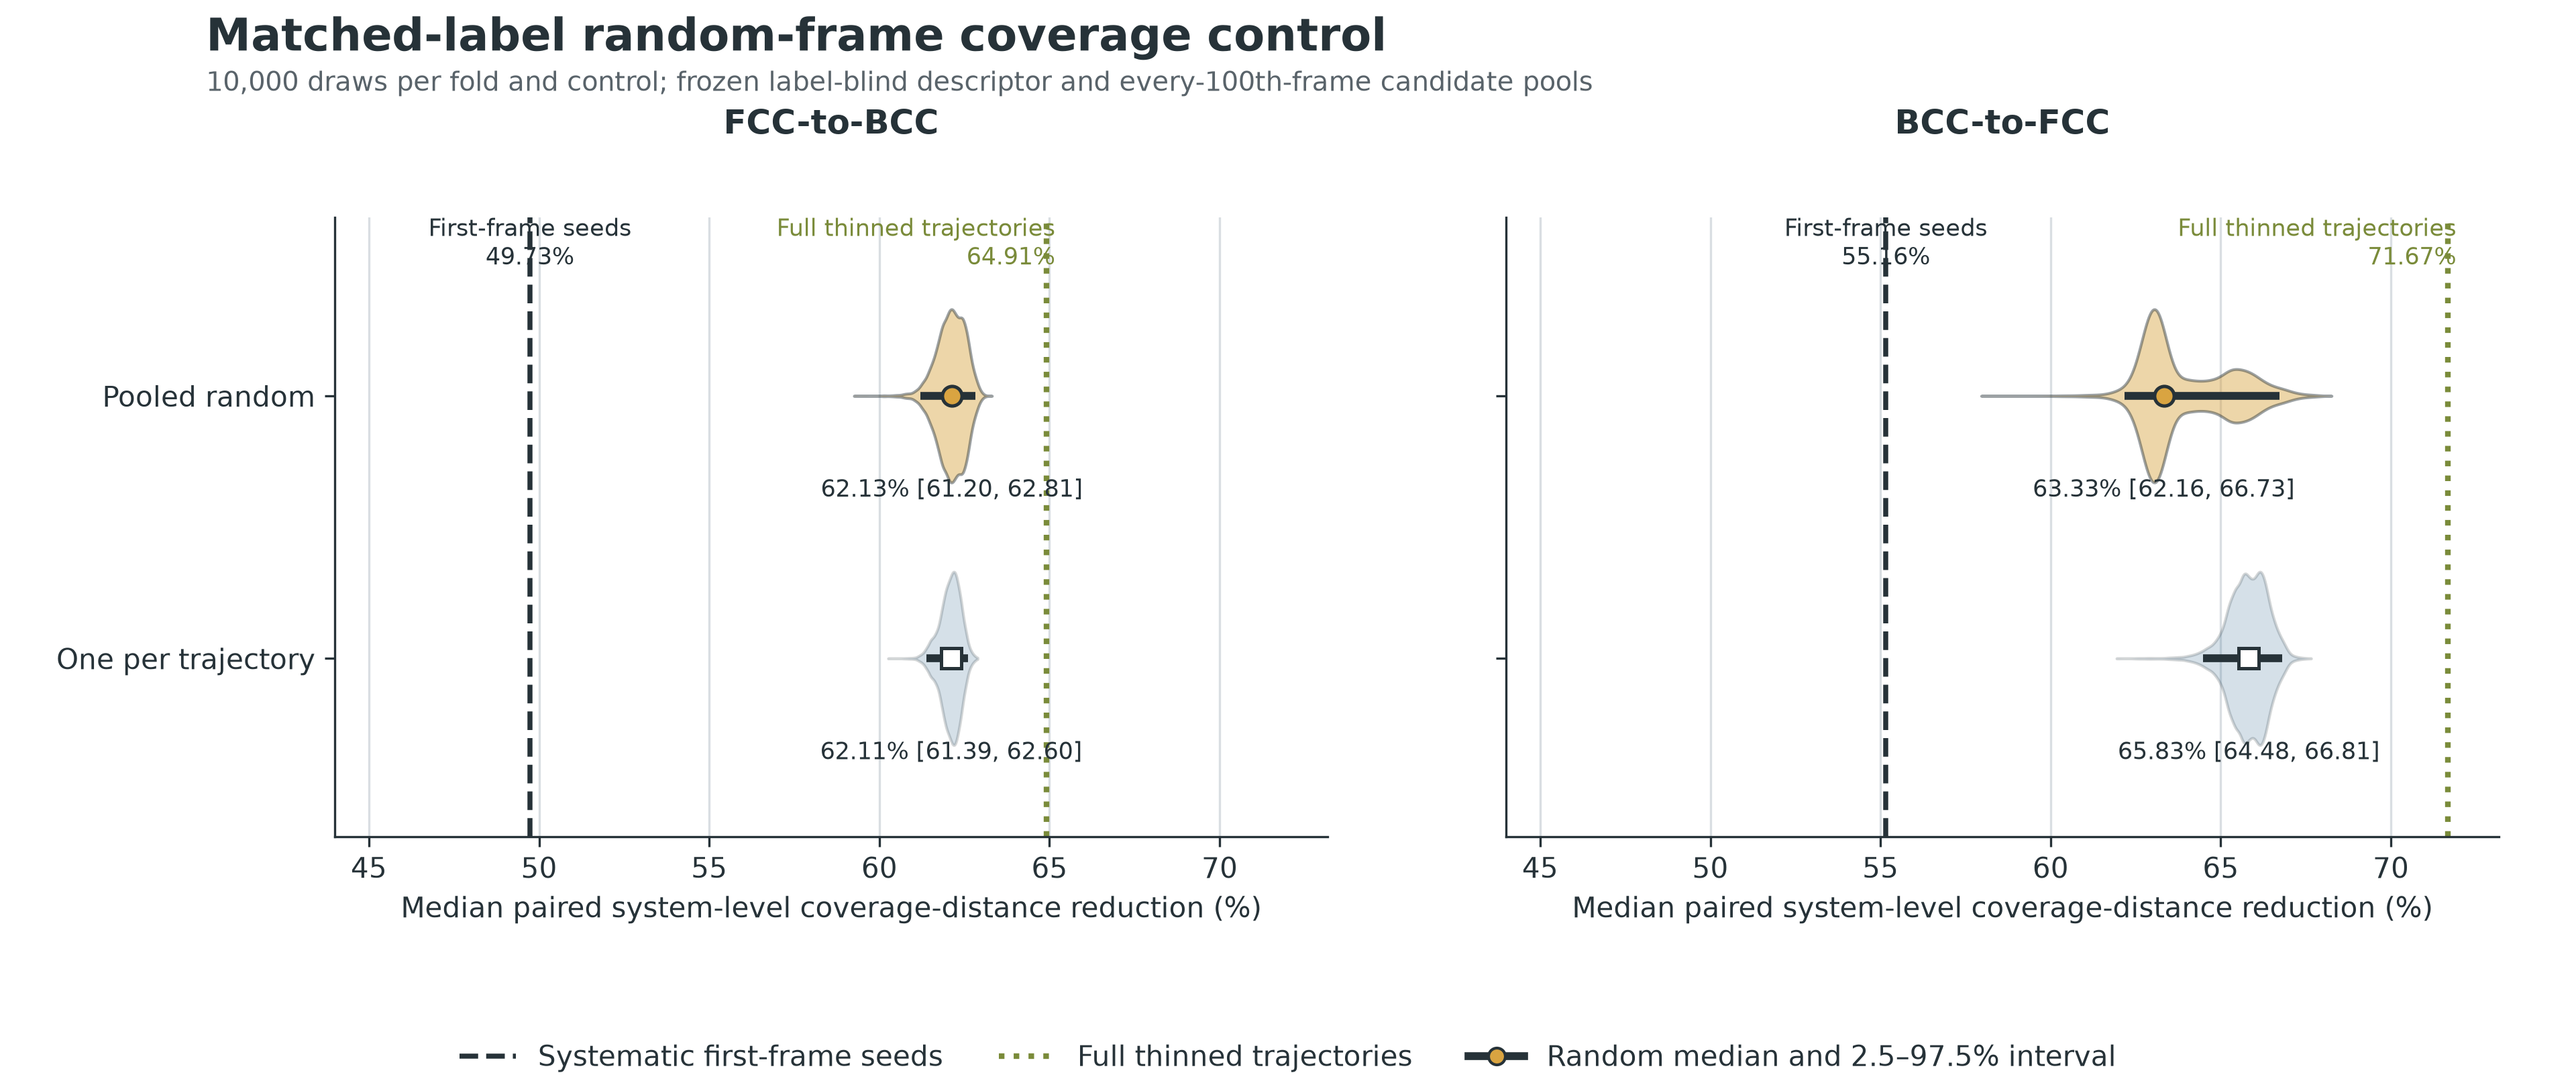

In [3]:
for fold in ['fcc_to_bcc', 'bcc_to_fcc']:
    observed = summary.loc[(summary.fold == fold) & (summary.control == 'pooled_random_frames'), 'systematic_seed_reduction_fraction'].iloc[0]
    values = draws.loc[(draws.fold == fold) & (draws.control == 'pooled_random_frames'), 'coverage_reduction_fraction'].to_numpy()
    print(f'{fold}: {np.count_nonzero(values > observed):,}/{len(values):,} pooled draws '+ 'exceed the systematic first-frame value')
display(Image(filename=str(PACKAGE / 'figures' / 'random_seed_coverage_control.png')))

## Takeaways

- **Matched random frames cover more descriptor space than the prescribed first frames.** Pooled random medians exceed the systematic values by 12.40 and 8.17 percentage points for FCC-to-BCC and BCC-to-FCC, respectively.
- **The result is not caused by pooled draws omitting trajectories.** Exactly one random frame per trajectory gives 62.11% [61.39, 62.60] and 65.83% [64.48, 66.81].
- **Claim calibration:** approximately 30 POCC-derived configurations provide substantial coverage at low label count, but the evidence does not support attributing that gain to the first-frame seed rule. Later thermal frames are a stronger matched-label coverage reference.
- **Boundary:** because every control frame comes from an existing POCC-derived trajectory, this analysis does not test whether POCC enumeration is superior to random-alloy, SQS, active-learning, or other structure-selection strategies, and it says nothing about model performance without training matched control models.